In [13]:
def find_survival_rate_mise_weibull(survival_rates, lambd, beta):
    squared_error = []
    for i in range(len(survival_rates)):
        t = i+1
        estimated_survival_rate = np.exp(-lambd * (t ** beta))
        squared_error.append((estimated_survival_rate - survival_rates[i]) ** 2)
    
    return np.mean(squared_error)

def find_hazard_rate_mise_weibull(survival_rates, lambd, beta):
    # calculate ground truth hazard rate
    hazard_rates = []
    for i in range(len(survival_rates)):
        if i == 0:
            hazard_rates.append(1 - survival_rates[i])
        else:
            hazard_rates.append(1 - survival_rates[i] / survival_rates[i-1])
    
    squared_error = []
    for i in range(len(survival_rates)):
        t = i + 1
        estimated_hazard_rate = 1 - np.exp(- lambd * (t ** beta - (t-1) ** beta))
        squared_error.append((hazard_rates[i] - estimated_hazard_rate) ** 2)
    return np.mean(squared_error)

def find_survival_rate_mise_error_rate(survival_rates, error_rate):
    squared_error = []
    for i in range(len(survival_rates)):
        t = i+1
        estimated_survival_rate = ((1-error_rate) ** t)
        squared_error.append((estimated_survival_rate - survival_rates[i]) ** 2)
    
    return np.mean(squared_error)



def find_hazard_rate_mise_error_rate(survival_rates, error_rate):
    # calculate ground truth hazard rate
    hazard_rates = []
    for i in range(len(survival_rates)):
        if i == 0:
            hazard_rates.append(1 - survival_rates[i])
        else:
            hazard_rates.append(1 - survival_rates[i] / survival_rates[i-1])
    
    squared_error = []
    for i in range(len(survival_rates)):
        estimated_hazard_rate = error_rate
        squared_error.append((hazard_rates[i] - estimated_hazard_rate) ** 2)
    return np.mean(squared_error)


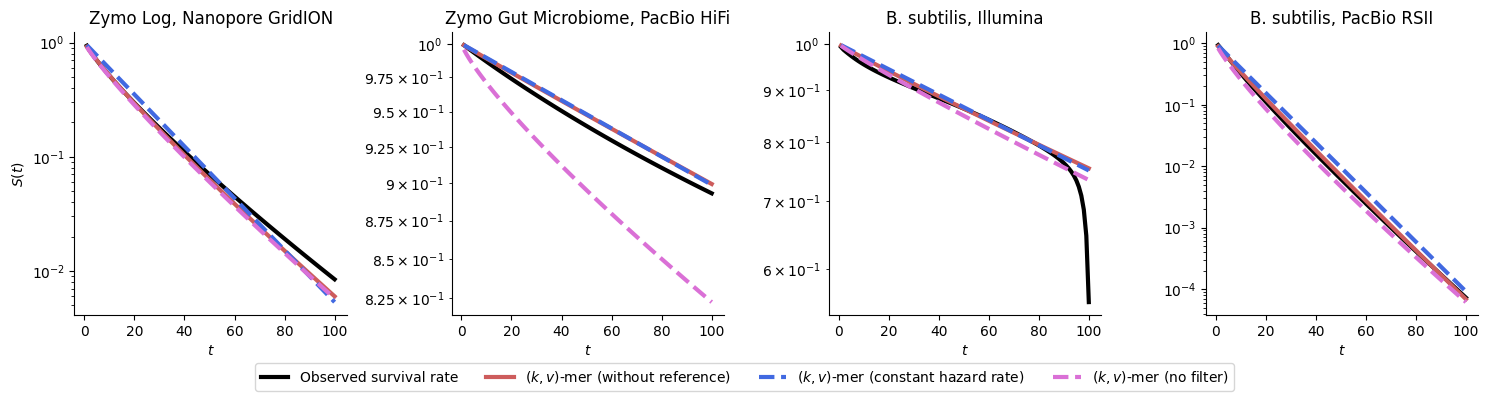

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import seaborn as sns

# Set seaborn style

# Define the function to fit
def fit_function_beta(i, alpha, beta):
    return alpha / (alpha + beta + i)

def fit_function_normal(i, mean, std):
    return np.exp(- mean + (i + 0.5) * (std * std))

def fit_function_weibull(i, a, b):
    return a * (i ** b)

def fit_function_gamma(i, alpha, beta):
    return (alpha * beta) / (1 + beta * i)

kmer_hit_rate_csv = [
    "../../output/zymo/ERR3152366.matched_kmers.csv",
    "../../output/zymo/SRR13128014.matched_kmers.csv",
    "../../output/zymo/ERR2935851_ref.matched_kmers.csv",
    "../../output/zymo/SRR7498042_ref.matched_kmers.csv",
    
]

labels = [
    "Zymo Log, Nanopore GridION",
    "Zymo Gut Microbiome, PacBio HiFi",
    "B. subtilis, Illumina",
    "B. subtilis, PacBio RSII",
    
]

kvmer_report_csv = [
    "../../output/zymo/ERR3152366_bi_kvmer.csv",
    "../../output/zymo/SRR13128014_bi_kvmer.csv",
    "../../output/zymo/ERR2935851_bi_kvmer.csv",
    "../../output/zymo/SRR7498042_bi_kvmer.csv",
    
    #"../../output/human/HG002_hifi_bi_kvmer.csv"
    
]

kvmer_ref_report_csv = [
    "../../output/zymo/ERR3152366_bi_kvmer_const.csv",
    "../../output/zymo/SRR13128014_bi_kvmer_const.csv",
    "../../output/zymo/ERR2935851_bi_kvmer_const.csv",
    "../../output/zymo/SRR7498042_bi_kvmer_const.csv",
    
    #"../../output/human/HG002_hifi_bi_kvmer_ref.csv"
]

kvmer_no_filt_report_csv = [
    "../../output/zymo/ERR3152366_bi_kvmer_no_filt.csv",
    "../../output/zymo/SRR13128014_bi_kvmer_no_filt.csv",
    "../../output/zymo/ERR2935851_bi_kvmer_no_filt.csv",
    "../../output/zymo/SRR7498042_bi_kvmer_no_filt.csv",
]

mapping_results = [
    # Reported mapping identity by minimap2
    0.883148,
    0.997772,
    0.992763,
    0.868784,
    
]

q_score_results = [
    # Reported ErrQ by seqtk
    16.7,
    82.9,
    27.7,
    9.0,
    
]

kmer_results = [
    # Reported error rate by GenomeScope
    3.72975,
    0.785707,
    0.613276,
    11.7262,
    
]



weibull_fit_results = []

for i in range(len(kvmer_report_csv)):
    kvmer_report_df = pd.read_csv(kvmer_report_csv[i])
    a = kvmer_report_df['lambda'].item()
    b = kvmer_report_df['beta'].item()
    weibull_fit_results.append((a, b))

weibull_fit_results_ref = []
for i in range(len(kvmer_ref_report_csv)):
    kvmer_report_df = pd.read_csv(kvmer_ref_report_csv[i])
    a = kvmer_report_df['lambda'].item()
    b = kvmer_report_df['beta'].item()
    weibull_fit_results_ref.append((a, b))

weibull_fit_results_no_filt = []
for i in range(len(kvmer_no_filt_report_csv)):
    kvmer_report_df = pd.read_csv(kvmer_no_filt_report_csv[i])
    a = kvmer_report_df['lambda'].item()
    b = kvmer_report_df['beta'].item()
    weibull_fit_results_no_filt.append((a, b))

def q_score_to_identity(q):
    return 1 - 10 ** (-q / 10)

def kmer_error_to_identity(e):
    return (1 - e / 100)

def estimate_survival_rate_from_identity(identity, k):
    return np.exp(-(1-identity) * k)

def estimate_survival_rate_list_from_beta(alpha, beta, max_k):
    survival_rates = []
    for k in range(1, max_k + 1):
        hazard_rate = fit_function_beta(k, alpha, beta)
        if k == 1:
            survival_rate = 1 - hazard_rate
        else:
            survival_rate = survival_rates[-1] * (1 - hazard_rate)
        survival_rates.append(survival_rate)
    return survival_rates

def estimate_survival_rate_from_weibull(l, b, k):
    return np.exp(- l * (k ** b))

# Plot in 3 separate figures, the hazard ratio and the predicted k-mer hit rate.
# The hazard ratio is calculated by matched_kmers(k) / matched_kmers(k-1)
font_size = 8  # Set a common font size for labels and titles
plot_range = range(1, 101)
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten()

survival_rate_mise = {
    "Kvmer": [],
    "Kvmer (const hazard)": [],
    "Kvmer (no filter)": [],
}

hazard_rate_mise = {
    "Kvmer": [],
    "Kvmer (const hazard)": [],
    "Kvmer (no filter)": [],
}

for i in range(len(kmer_hit_rate_csv)):
    kmer_hit_rate_df = pd.read_csv(kmer_hit_rate_csv[i])
    survival_rates = kmer_hit_rate_df['num_kmer_hit'].values
    survival_rates_plot = survival_rates[plot_range.start - 1:plot_range.stop - 1]

    # Calculate the survival rate for mapping
    survival_rates_mapping = []
    for k in plot_range:
        survival_rate = estimate_survival_rate_from_identity(mapping_results[i], k)
        survival_rates_mapping.append(survival_rate)
    
    survival_rates_qscore = []
    for k in plot_range:
        survival_rate = estimate_survival_rate_from_identity(q_score_to_identity(q_score_results[i]), k)
        survival_rates_qscore.append(survival_rate)
    
    survival_rates_kmer = []
    for k in plot_range:
        survival_rate = estimate_survival_rate_from_identity(kmer_error_to_identity(kmer_results[i]), k)
        survival_rates_kmer.append(survival_rate)
    
    
        
        
    
    #survival_rates_beta = estimate_survival_rate_list_from_beta(beta_fit_results[i][0], beta_fit_results[i][1], plot_range.stop - 1)
    #survival_rates_beta = survival_rates_beta[plot_range.start - 1:plot_range.stop - 1]

    #survival_rates_const_hazard = []
    #for k in plot_range:
    #    survival_rate = (1 - (beta_fit_results[i][0] / (beta_fit_results[i][0] + beta_fit_results[i][1]))) ** k
    #    survival_rates_const_hazard.append(survival_rate)

    survival_rates_weibull = []
    survival_rates_weibull_ref = []
    survival_rates_no_filt = []
    for k in plot_range:
        survival_rate = estimate_survival_rate_from_weibull(weibull_fit_results[i][0], weibull_fit_results[i][1], k)
        surival_rate_ref = estimate_survival_rate_from_weibull(weibull_fit_results_ref[i][0], weibull_fit_results_ref[i][1], k)
        survival_rate_no_filt = estimate_survival_rate_from_weibull(weibull_fit_results_no_filt[i][0], weibull_fit_results_no_filt[i][1], k)
        survival_rates_weibull.append(survival_rate)
        survival_rates_weibull_ref.append(surival_rate_ref)
        survival_rates_no_filt.append(survival_rate_no_filt)
    
    survival_rate_mise['Kvmer'].append(
        find_survival_rate_mise_weibull(survival_rates_plot, weibull_fit_results[i][0], weibull_fit_results[i][1])
        )
    survival_rate_mise['Kvmer (const hazard)'].append(
        find_survival_rate_mise_weibull(survival_rates_plot, weibull_fit_results_ref[i][0], weibull_fit_results_ref[i][1])
        )
    survival_rate_mise['Kvmer (no filter)'].append(
        find_survival_rate_mise_weibull(survival_rates_plot, weibull_fit_results_no_filt[i][0], weibull_fit_results_no_filt[i][1])
        )
    

    hazard_rate_mise['Kvmer'].append(
        find_hazard_rate_mise_weibull(survival_rates_plot, weibull_fit_results[i][0], weibull_fit_results[i][1])
        )
    hazard_rate_mise['Kvmer (const hazard)'].append(
        find_hazard_rate_mise_weibull(survival_rates_plot, weibull_fit_results_ref[i][0], weibull_fit_results_ref[i][1])
        )
    hazard_rate_mise['Kvmer (no filter)'].append(
        find_hazard_rate_mise_weibull(survival_rates_plot, weibull_fit_results_no_filt[i][0], weibull_fit_results_no_filt[i][1])
        )


    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)



    axes[i].plot(plot_range, survival_rates_plot, linewidth=3, label='Observed survival rate', color='black')
    #axes[i].plot(plot_range, survival_rates_mapping, linewidth=3, linestyle='--', label='Minimap2 + BEST', color='slategray')
    #axes[i].plot(plot_range, survival_rates_qscore, linewidth=3, linestyle='--', label='seqtk', color='cornflowerblue')
    #axes[i].plot(plot_range, survival_rates_kmer, linewidth=3, linestyle='--', label='KMC + Genomescope2.0', color='darkseagreen')
    #axes[i].plot(plot_range, survival_rates_beta, linewidth=2, linestyle='-', label='Predicted from Beta Fit', color='C4')
    #axes[i].plot(plot_range, survival_rates_const_hazard, linewidth=2, linestyle='--', label='Predicted from Constant Hazard', color='C5')
    axes[i].plot(plot_range, survival_rates_weibull, linewidth=3, label='$(k,v)$-mer (without reference)', color='indianred')
    axes[i].plot(plot_range, survival_rates_weibull_ref, linewidth=3, linestyle='--', label='$(k,v)$-mer (constant hazard rate)', color='royalblue')
    axes[i].plot(plot_range, survival_rates_no_filt, linewidth=3, linestyle='--', label='$(k,v)$-mer (no filter)', color='orchid')

    axes[i].set_yscale('log')
    #axes[i].set_xscale('log')
    
    
    
    axes[i].tick_params(axis='both')

    axes[i].set_title(labels[i])
    
    axes[i].set_xlabel('$t$')
    if i  == 0:
        axes[i].set_ylabel('$S(t)$')
    #axes[i].legend()
    #axes[i].legend()

handles, labels = axes[0].get_legend_handles_labels()
plt.tight_layout()

# Add the legend to the bottom of the figure
fig.legend(handles, labels, loc='lower center', ncol=6)
fig.subplots_adjust(bottom=0.2)
#plt.tight_layout()


plt.savefig("../../figures/metagenomics_ablation_study.pdf")
#plt.ylim(0, 0.05)

In [3]:
hazard_rate_mise

{'Kvmer': [np.float64(1.7351147564034976e-05),
  np.float64(3.4006182047634286e-08),
  np.float64(7.300427524576797e-07),
  np.float64(6.306463071178612e-05)],
 'Kvmer (const hazard)': [np.float64(6.002428416377108e-05),
  np.float64(3.877188898170426e-08),
  np.float64(1.041601480266769e-06),
  np.float64(0.00013221452699170946)],
 'Kvmer (no filter)': [np.float64(2.2018071168686512e-05),
  np.float64(1.1320679698255123e-06),
  np.float64(6.76187062966143e-07),
  np.float64(0.0002489164501636016)]}

In [7]:
weibull_results = [1 - np.exp(-weibull_fit_results[i][0]) for i in range(len(weibull_fit_results))]
weibull_results_ref = [1 - np.exp(-weibull_fit_results_ref[i][0]) for i in range(len(weibull_fit_results_ref))]
weibull_results_no_filt = [1 - np.exp(-weibull_fit_results_no_filt[i][0]) for i in range(len(weibull_fit_results_no_filt))]

results_df = pd.DataFrame({
    "kvmer": weibull_results,
    "kvmer constant": weibull_results_ref,
    "kvmer no filter": weibull_results_no_filt,
})
results_df 

,kvmer,kvmer constant,kvmer no filter
0,0.082187,0.050997,0.087169
1,0.001160,0.001065,0.004485
2,0.003637,0.002868,0.004402
3,0.112971,0.088772,0.173049


[(0.010954, 0.89838), (0.041127, 0.856912), (0.002253, 0.886855)]
[0.97985403 0.95559578 0.93605869 0.92032291 0.90739069 0.8964343
 0.88685251 0.87825442 0.87039761 0.86312422 0.8563141  0.84988008
 0.84376144 0.83790909 0.8322873  0.82686414 0.8216142  0.81651699
 0.81155617 0.80671709 0.80198854 0.79736122 0.79282623 0.78837642
 0.78400613 0.77970964 0.77548198 0.77131887 0.76721649 0.76317137
 0.75918118 0.75524299 0.75135442 0.74751382 0.74371946 0.7399687
 0.73625966 0.73259118 0.72896205 0.72537097 0.72181688 0.71829841
 0.71481407 0.71136318 0.70794467 0.7045578  0.70120187 0.69787595
 0.6945796 ]
0.010954 0.89838
0.001281164554908956
[0.91077029 0.80576366 0.72518212 0.66088777 0.60682531 0.56008926
 0.51902567 0.48259217 0.45003489 0.42073372 0.3942041  0.37005944
 0.34799549 0.32776438 0.30915397 0.29198285 0.27609407 0.26136163
 0.24767248 0.23493045 0.22305974 0.21198185 0.20162904 0.19194206
 0.18286923 0.17436262 0.16637453 0.15886883 0.15180374 0.14515211
 0.13888392 0.

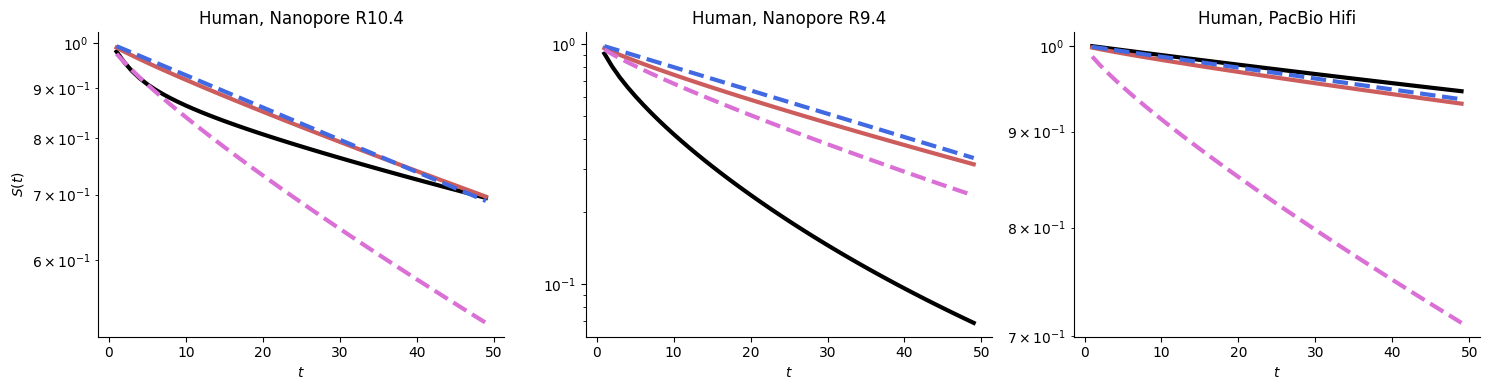

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import seaborn as sns

# Set seaborn style

# Define the function to fit
def fit_function_beta(i, alpha, beta):
    return alpha / (alpha + beta + i)

def fit_function_normal(i, mean, std):
    return np.exp(- mean + (i + 0.5) * (std * std))

def fit_function_weibull(i, a, b):
    return a * (i ** b)

def fit_function_gamma(i, alpha, beta):
    return (alpha * beta) / (1 + beta * i)

kmer_hit_rate_csv = [
    "../../output/human/HG002.bam.tmp.0000.matched_kmers.csv",
    "../../output/human/HG002_R941.bam.tmp.0000.matched_kmers.csv",
    "../../output/human/HG002_hifi.bam.tmp.0000.matched_kmers.csv",
]


labels = [
    "Human, Nanopore R10.4",
    "Human, Nanopore R9.4",
    "Human, PacBio Hifi",
]

kvmer_report_csv = [
    "../../output/human/HG002_bi_kvmer.csv",
    "../../output/human/HG002_R941_bi_kvmer.csv",
    "../../output/human/HG002_hifi_bi_kvmer.csv",
]

kvmer_ref_report_csv = [
    "../../output/human/HG002_bi_kvmer_const.csv",
    "../../output/human/HG002_R941_bi_kvmer_const.csv",
    "../../output/human/HG002_hifi_bi_kvmer_const.csv",
]

kvmer_no_filt_report_csv = [
    "../../output/human/HG002_bi_kvmer_no_filt.csv",
    "../../output/human/HG002_R941_bi_kvmer_no_filt.csv",
    "../../output/human/HG002_hifi_bi_kvmer_no_filt.csv",
]





mapping_results = [
    # Reported mapping identity by minimap2
    0.963613, # R10.4
    0.838991, # r9.4.1
    0.998709 # hifi
]

q_score_results = [
    # Reported ErrQ by seqtk
    30.1, # R10.4
    19.6, # R9.4.1
    38.5 # hifi
]

kmer_results = [
    # Reported error rate by GenomeScope
    1.076, # R10.4
    5.18148, # R9.4.1
    0.0814363, #hifi
]


weibull_fit_results = []

for i in range(len(kvmer_report_csv)):
    kvmer_report_df = pd.read_csv(kvmer_report_csv[i])
    a = kvmer_report_df['lambda'].item()
    b = kvmer_report_df['beta'].item()
    weibull_fit_results.append((a, b))

weibull_fit_results_ref = []
for i in range(len(kvmer_ref_report_csv)):
    kvmer_report_df = pd.read_csv(kvmer_ref_report_csv[i])
    a = kvmer_report_df['lambda'].item()
    b = kvmer_report_df['beta'].item()
    weibull_fit_results_ref.append((a, b))

weibull_fit_results_no_filt = []
for i in range(len(kvmer_no_filt_report_csv)):
    kvmer_report_df = pd.read_csv(kvmer_no_filt_report_csv[i])
    a = kvmer_report_df['lambda'].item()
    b = kvmer_report_df['beta'].item()
    weibull_fit_results_no_filt.append((a, b))

print(weibull_fit_results)

def q_score_to_identity(q):
    return 1 - 10 ** (-q / 10)

def kmer_error_to_identity(e):
    return (1 - e / 100)

def estimate_survival_rate_from_identity(identity, k):
    return np.exp(-(1-identity) * k)

def estimate_survival_rate_list_from_beta(alpha, beta, max_k):
    survival_rates = []
    for k in range(1, max_k + 1):
        hazard_rate = fit_function_beta(k, alpha, beta)
        if k == 1:
            survival_rate = 1 - hazard_rate
        else:
            survival_rate = survival_rates[-1] * (1 - hazard_rate)
        survival_rates.append(survival_rate)
    return survival_rates

def estimate_survival_rate_from_weibull(a, b, k):
    return np.exp(- a * (k ** b))

# Plot in 3 separate figures, the hazard ratio and the predicted k-mer hit rate.
# The hazard ratio is calculated by matched_kmers(k) / matched_kmers(k-1)
font_size = 8  # Set a common font size for labels and titles
plot_range = range(1, 50)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes = axes.flatten()

for i in range(len(kmer_hit_rate_csv)):
    kmer_hit_rate_df = pd.read_csv(kmer_hit_rate_csv[i])
    survival_rates = kmer_hit_rate_df['num_kmer_hit'].values
    survival_rates_plot = survival_rates[plot_range.start - 1:plot_range.stop - 1]

    # Calculate the survival rate for mapping
    survival_rates_mapping = []
    for k in plot_range:
        survival_rate = estimate_survival_rate_from_identity(mapping_results[i], k)
        survival_rates_mapping.append(survival_rate)
    
    survival_rates_qscore = []
    for k in plot_range:
        survival_rate = estimate_survival_rate_from_identity(q_score_to_identity(q_score_results[i]), k)
        survival_rates_qscore.append(survival_rate)
    
    survival_rates_kmer = []
    for k in plot_range:
        survival_rate = estimate_survival_rate_from_identity(kmer_error_to_identity(kmer_results[i]), k)
        survival_rates_kmer.append(survival_rate)
    
    #survival_rates_beta = estimate_survival_rate_list_from_beta(beta_fit_results[i][0], beta_fit_results[i][1], plot_range.stop - 1)
    #survival_rates_beta = survival_rates_beta[plot_range.start - 1:plot_range.stop - 1]

    #survival_rates_const_hazard = []
    #for k in plot_range:
    #    survival_rate = (1 - (beta_fit_results[i][0] / (beta_fit_results[i][0] + beta_fit_results[i][1]))) ** k
    #    survival_rates_const_hazard.append(survival_rate)

    survival_rates_weibull = []
    survival_rates_weibull_ref = []
    survival_rates_no_filt = []
    for k in plot_range:
        survival_rate = estimate_survival_rate_from_weibull(weibull_fit_results[i][0], weibull_fit_results[i][1], k)
        surival_rate_ref = estimate_survival_rate_from_weibull(weibull_fit_results_ref[i][0], weibull_fit_results_ref[i][1], k)
        survival_rate_no_filt = estimate_survival_rate_from_weibull(weibull_fit_results_no_filt[i][0], weibull_fit_results_no_filt[i][1], k)
        survival_rates_weibull.append(survival_rate)
        survival_rates_weibull_ref.append(surival_rate_ref)
        survival_rates_no_filt.append(survival_rate_no_filt)
    
    survival_rate_mise['Kvmer'].append(
        find_survival_rate_mise_weibull(survival_rates_plot, weibull_fit_results[i][0], weibull_fit_results[i][1])
        )
    survival_rate_mise['Kvmer (const hazard)'].append(
        find_survival_rate_mise_weibull(survival_rates_plot, weibull_fit_results_ref[i][0], weibull_fit_results_ref[i][1])
        )
    survival_rate_mise['Kvmer (no filter)'].append(
        find_survival_rate_mise_weibull(survival_rates_plot, weibull_fit_results_no_filt[i][0], weibull_fit_results_no_filt[i][1])
        )
    

    hazard_rate_mise['Kvmer'].append(
        find_hazard_rate_mise_weibull(survival_rates_plot, weibull_fit_results[i][0], weibull_fit_results[i][1])
        )
    hazard_rate_mise['Kvmer (const hazard)'].append(
        find_hazard_rate_mise_weibull(survival_rates_plot, weibull_fit_results_ref[i][0], weibull_fit_results_ref[i][1])
        )
    hazard_rate_mise['Kvmer (no filter)'].append(
        find_hazard_rate_mise_weibull(survival_rates_plot, weibull_fit_results_no_filt[i][0], weibull_fit_results_no_filt[i][1])
        )

    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

    print(survival_rates_plot)

    print(weibull_fit_results[i][0], weibull_fit_results[i][1])
    print(find_survival_rate_mise_weibull(survival_rates_plot, weibull_fit_results[i][0], weibull_fit_results[i][1])) 

    axes[i].plot(plot_range, survival_rates_plot, linewidth=3, label='Observed survival rate', color='black')
    #axes[i].plot(plot_range, survival_rates_mapping, linewidth=3, linestyle='--', label='Minimap2 + BEST', color='slategray')
    #axes[i].plot(plot_range, survival_rates_qscore, linewidth=3, linestyle='--', label='seqtk', color='cornflowerblue')
    #axes[i].plot(plot_range, survival_rates_kmer, linewidth=3, linestyle='--', label='KMC + Genomescope2.0', color='darkseagreen')
    #axes[i].plot(plot_range, survival_rates_beta, linewidth=2, linestyle='-', label='Predicted from Beta Fit', color='C4')
    #axes[i].plot(plot_range, survival_rates_const_hazard, linewidth=2, linestyle='--', label='Predicted from Constant Hazard', color='C5')
    axes[i].plot(plot_range, survival_rates_weibull, linewidth=3, label='$(k,v)$-mer (without reference)', color='indianred')
    axes[i].plot(plot_range, survival_rates_weibull_ref, linewidth=3, linestyle='--', label='$(k,v)$-mer (constant hazard rate)', color='royalblue')
    axes[i].plot(plot_range, survival_rates_no_filt, linewidth=3, linestyle='--', label='$(k,v)$-mer (no filter)', color='orchid')

   
    axes[i].set_yscale('log')
    #axes[i].set_xscale('log')
    
    
    
    axes[i].tick_params(axis='both')

    axes[i].set_title(labels[i])
    
    axes[i].set_xlabel('$t$')
    if i  == 0:
        axes[i].set_ylabel('$S(t)$')
    #axes[i].legend()
    #axes[i].legend()

handles, labels = axes[0].get_legend_handles_labels()
plt.tight_layout()

# Add the legend to the bottom of the figure
#fig.legend(handles, labels, loc='lower center', ncol=6)
#fig.subplots_adjust(bottom=0.2)
#plt.tight_layout()


plt.savefig("../../figures/human_ablation_study.pdf")
#plt.ylim(0, 0.05)

In [14]:
survival_rate_mise_all = pd.DataFrame(survival_rate_mise)
survival_rate_mise_all.style.format("{:.2e}")

,Kvmer,Kvmer (const hazard),Kvmer (no filter)
0,2.95e-05,1.13e-03,8.95e-05
1,4.51e-05,4.74e-05,2.16e-03
2,6.76e-04,6.73e-04,5.72e-04
3,8.67e-05,7.29e-04,1.17e-03


In [7]:
hazard_rate_mise_all = pd.DataFrame(hazard_rate_mise)
hazard_rate_mise_all.style.format("{:.2e}")

,Kvmer,Kvmer (const hazard),Kvmer (no filter)
0,1.74e-05,6.00e-05,2.20e-05
1,3.40e-08,3.88e-08,1.13e-06
2,7.30e-07,1.04e-06,6.76e-07
3,6.31e-05,1.32e-04,2.49e-04
4,1.37e-05,1.97e-05,4.07e-05
5,1.10e-03,1.28e-03,7.44e-04
6,1.52e-07,5.16e-08,3.53e-05


Bad pipe message: %s [b'd\x05}T\xaa\xf4\xdcMP\x17a\x16\xb5:\xc4\xbc\xa3\xb6\x00\x02\xbc\x00\x00\x00\x01\x00\x02\x00\x03\x00\x04\x00\x05\x00\x06\x00\x07\x00\x08\x00\t\x00\n\x00\x0b\x00\x0c\x00\r\x00\x0e\x00\x0f\x00\x10\x00\x11\x00\x12\x00\x13\x00\x14\x00\x15\x00\x16\x00\x17\x00\x18\x00\x19\x00\x1a\x00\x1b\x00\x1e\x00\x1f\x00 \x00!\x00"\x00#\x00$\x00%\x00&\x00\'\x00(\x00)\x00*\x00+\x00,\x00-\x00.\x00/\x000\x001\x002\x003\x004\x005\x006\x007\x008\x009\x00:\x00;\x00<\x00=\x00>\x00?\x00@\x00A\x00B\x00C\x00D\x00E\x00F\x00g\x00h\x00i\x00j\x00k\x00']
Bad pipe message: %s [b'm\x00\x84\x00\x85\x00\x86\x00\x87\x00\x88\x00\x89\x00\x8a\x00\x8b\x00\x8c\x00\x8d\x00\x8e\x00\x8f\x00\x90\x00\x91\x00\x92\x00\x93\x00\x94\x00\x95\x00\x96\x00\x97\x00\x98\x00\x99\x00\x9a\x00\x9b\x00\x9c\x00\x9d\x00\x9e\x00\x9f\x00\xa0\x00\xa1\x00\xa2\x00\xa3\x00\xa4\x00\xa5\x00\xa6\x00\xa7\x00\xa8\x00\xa9\x00\xaa\x00\xab\x00\xac\x00\xad\x00\xae\x00\xaf\x00\xb0\x00\xb1\x00\xb2\x00\xb3\x00\xb4\x00\xb5\x00\xb6\x00\xb7\x00\xb8']

In [9]:
weibull_results = [1 - np.exp(-weibull_fit_results[i][0]) for i in range(len(weibull_fit_results))]
weibull_results_ref = [1 - np.exp(-weibull_fit_results_ref[i][0]) for i in range(len(weibull_fit_results_ref))]
weibull_results_no_filt = [1 - np.exp(-weibull_fit_results_no_filt[i][0]) for i in range(len(weibull_fit_results_no_filt))]

results_df = pd.DataFrame({
    "kvmer": weibull_results,
    "kvmer constant": weibull_results_ref,
    "kvmer no filter": weibull_results_no_filt,
})
results_df 

,kvmer,kvmer constant,kvmer no filter
0,0.010893,0.007554,0.025170
1,0.040282,0.022086,0.053240
2,0.002235,0.001340,0.013144
